
# # Soil Health Classification Model
# 
# *Project Goal*: Develop an accurate stacking classifier to predict soil health categories
# *Solution Approach*: 
# 1. Comprehensive data analysis
# 2. Feature engineering
# 3. Ensemble methods (Stacking Classifier)
# 4. Rigorous evaluation



In [15]:
# ============================================
# CELL 1: IMPORT LIBRARIES WITH PURPOSE
# ============================================
print("="*60)
print("CELL 1: IMPORTING REQUIRED LIBRARIES")
print("PURPOSE: Load all necessary packages for data analysis and ML")
print("="*60)

# Data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Model persistence
import pickle
import os
import json
from datetime import datetime

print("✅ All libraries imported successfully!")

CELL 1: IMPORTING REQUIRED LIBRARIES
PURPOSE: Load all necessary packages for data analysis and ML
✅ All libraries imported successfully!


In [5]:
# %% [code]
# ============================================
# CELL 2: DATA LOADING AND INITIAL INSPECTION
# ============================================
print("\n" + "="*60)
print("CELL 2: DATA LOADING AND INITIAL INSPECTION")
print("PURPOSE: Load dataset and understand its structure")
print("="*60)

# Define data path
DATA_PATH = 'E:/SPACE INF/soil-health-project/data/soil_health.csv'
print(f"📂 Loading data from: {DATA_PATH}")

try:
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Data loaded successfully! Shape: {df.shape}")
except FileNotFoundError:
    print(f"❌ File not found at {DATA_PATH}")
    print("Trying alternative paths...")
    # Try alternative path
    DATA_PATH = 'E:/SPACE INF/soil-health-project/data/soil_health.csv'
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Data loaded from alternative path! Shape: {df.shape}")

# Initial data inspection
print("\n📊 DATASET OVERVIEW:")
print("-" * 40)
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")

print("\n📋 DATA TYPES:")
print(df.dtypes)

print("\n🔍 FIRST 5 ROWS:")
display(df.head())

print("\n🧮 BASIC STATISTICS:")
display(df.describe())

print("\n❓ MISSING VALUES:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("✅ No missing values found!")

# %% [code]


CELL 2: DATA LOADING AND INITIAL INSPECTION
PURPOSE: Load dataset and understand its structure
📂 Loading data from: E:/SPACE INF/soil-health-project/data/soil_health.csv
✅ Data loaded successfully! Shape: (1288, 13)

📊 DATASET OVERVIEW:
----------------------------------------
Number of samples: 1288
Number of features: 13

Column names: ['N', 'P', 'K', 'ph', 'ec', 'oc', 'S', 'zn', 'fe', 'cu', 'Mn', 'B', 'fertility']

📋 DATA TYPES:
N              int64
P            float64
K              int64
ph           float64
ec           float64
oc           float64
S            float64
zn           float64
fe           float64
cu           float64
Mn           float64
B            float64
fertility      int64
dtype: object

🔍 FIRST 5 ROWS:


,N,P,K,ph,ec,oc,S,zn,fe,cu,Mn,B,fertility
0,138,8.6,560,7.46,0.62,0.70,5.9,0.24,0.31,0.77,8.71,0.11,0
1,213,7.5,338,7.62,0.75,1.06,25.4,0.30,0.86,1.54,2.89,2.29,0
2,163,9.6,718,7.59,0.51,1.11,14.3,0.30,0.86,1.57,2.70,2.03,0
3,157,6.8,475,7.64,0.58,0.94,26.0,0.34,0.54,1.53,2.65,1.82,0
4,220,8.6,444,7.43,0.65,0.72,11.7,0.37,0.66,0.90,2.19,1.82,0



🧮 BASIC STATISTICS:


,N,P,K,ph,ec,oc,S,zn,fe,cu,Mn,B,fertility
count,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000,1288.000000
mean,269.061335,17.643478,497.135093,7.549130,0.535893,0.632174,7.122888,0.442811,4.119185,0.911281,8.601530,0.611957,1.035714
std,80.542499,25.303343,120.887088,0.507163,0.134156,0.720488,4.026723,1.568333,3.028314,0.448782,4.466209,0.560781,0.810938
min,6.000000,2.900000,11.000000,0.900000,0.100000,0.100000,0.640000,0.070000,0.210000,0.090000,0.110000,0.060000,0.000000
25%,207.000000,7.200000,422.000000,7.340000,0.430000,0.390000,4.520000,0.280000,1.360000,0.600000,6.045000,0.290000,0.000000
50%,289.000000,9.200000,465.000000,7.500000,0.530000,0.620000,6.330000,0.360000,3.740000,0.890000,8.540000,0.420000,1.000000
75%,333.000000,13.800000,570.000000,7.700000,0.630000,0.832500,8.450000,0.480000,6.320000,1.250000,11.560000,0.650000,2.000000
max,383.000000,125.000000,887.000000,11.150000,0.950000,24.000000,31.000000,42.000000,44.000000,3.020000,31.000000,2.820000,2.000000



❓ MISSING VALUES:
Series([], dtype: int64)
✅ No missing values found!



CELL 3: TARGET VARIABLE ANALYSIS
PURPOSE: Understand the distribution and characteristics of target classes
🎯 Target column identified: 'fertility'

📊 TARGET CLASS DISTRIBUTION:
fertility
2    447
1    440
0    401
Name: count, dtype: int64

📈 CLASS DISTRIBUTION (PERCENTAGES):
  2: 34.70%
  1: 34.16%
  0: 31.13%


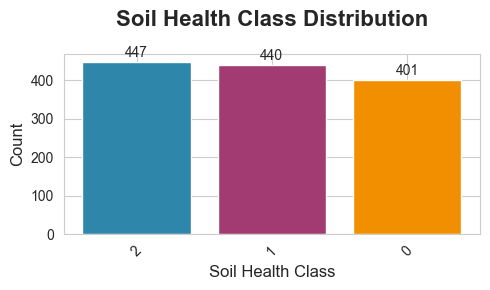


📊 Number of unique classes: 3
📊 Classes: [0, 1, 2]

⚖️ Class Imbalance Check:
  Most frequent class: 447 samples
  Least frequent class: 401 samples
  Imbalance ratio: 1.11
  ✅ Classes are relatively balanced


In [7]:
# %% [code]
# ============================================
# CELL 3: TARGET VARIABLE ANALYSIS
# ============================================
print("\n" + "="*60)
print("CELL 3: TARGET VARIABLE ANALYSIS")
print("PURPOSE: Understand the distribution and characteristics of target classes")
print("="*60)

# Identify target column (assuming last column)
target_col = df.columns[-1]
print(f"🎯 Target column identified: '{target_col}'")

# Analyze target distribution
print("\n📊 TARGET CLASS DISTRIBUTION:")
class_distribution = df[target_col].value_counts()
print(class_distribution)

print("\n📈 CLASS DISTRIBUTION (PERCENTAGES):")
class_percentages = df[target_col].value_counts(normalize=True) * 100
for class_name, percentage in class_percentages.items():
    print(f"  {class_name}: {percentage:.2f}%")

# Visualize class distribution
plt.figure(figsize=(5,3))
bars = plt.bar(class_distribution.index.astype(str), class_distribution.values, 
               color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
plt.title('Soil Health Class Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Soil Health Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

# Add count labels on bars
for bar, count in zip(bars, class_distribution.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 Number of unique classes: {df[target_col].nunique()}")
print(f"📊 Classes: {df[target_col].unique().tolist()}")

# Check for class imbalance
print(f"\n⚖️ Class Imbalance Check:")
min_class = class_distribution.min()
max_class = class_distribution.max()
imbalance_ratio = max_class / min_class
print(f"  Most frequent class: {max_class} samples")
print(f"  Least frequent class: {min_class} samples")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 3:
    print("  ⚠️ Significant class imbalance detected - will use class_weight='balanced'")
else:
    print("  ✅ Classes are relatively balanced")

# %% [code]


CELL 4: FEATURE ANALYSIS AND VISUALIZATION
PURPOSE: Analyze feature distributions and relationships
🔍 Analyzing 12 features: ['N', 'P', 'K', 'ph', 'ec', 'oc', 'S', 'zn', 'fe', 'cu', 'Mn', 'B']

📊 FEATURE DISTRIBUTIONS:


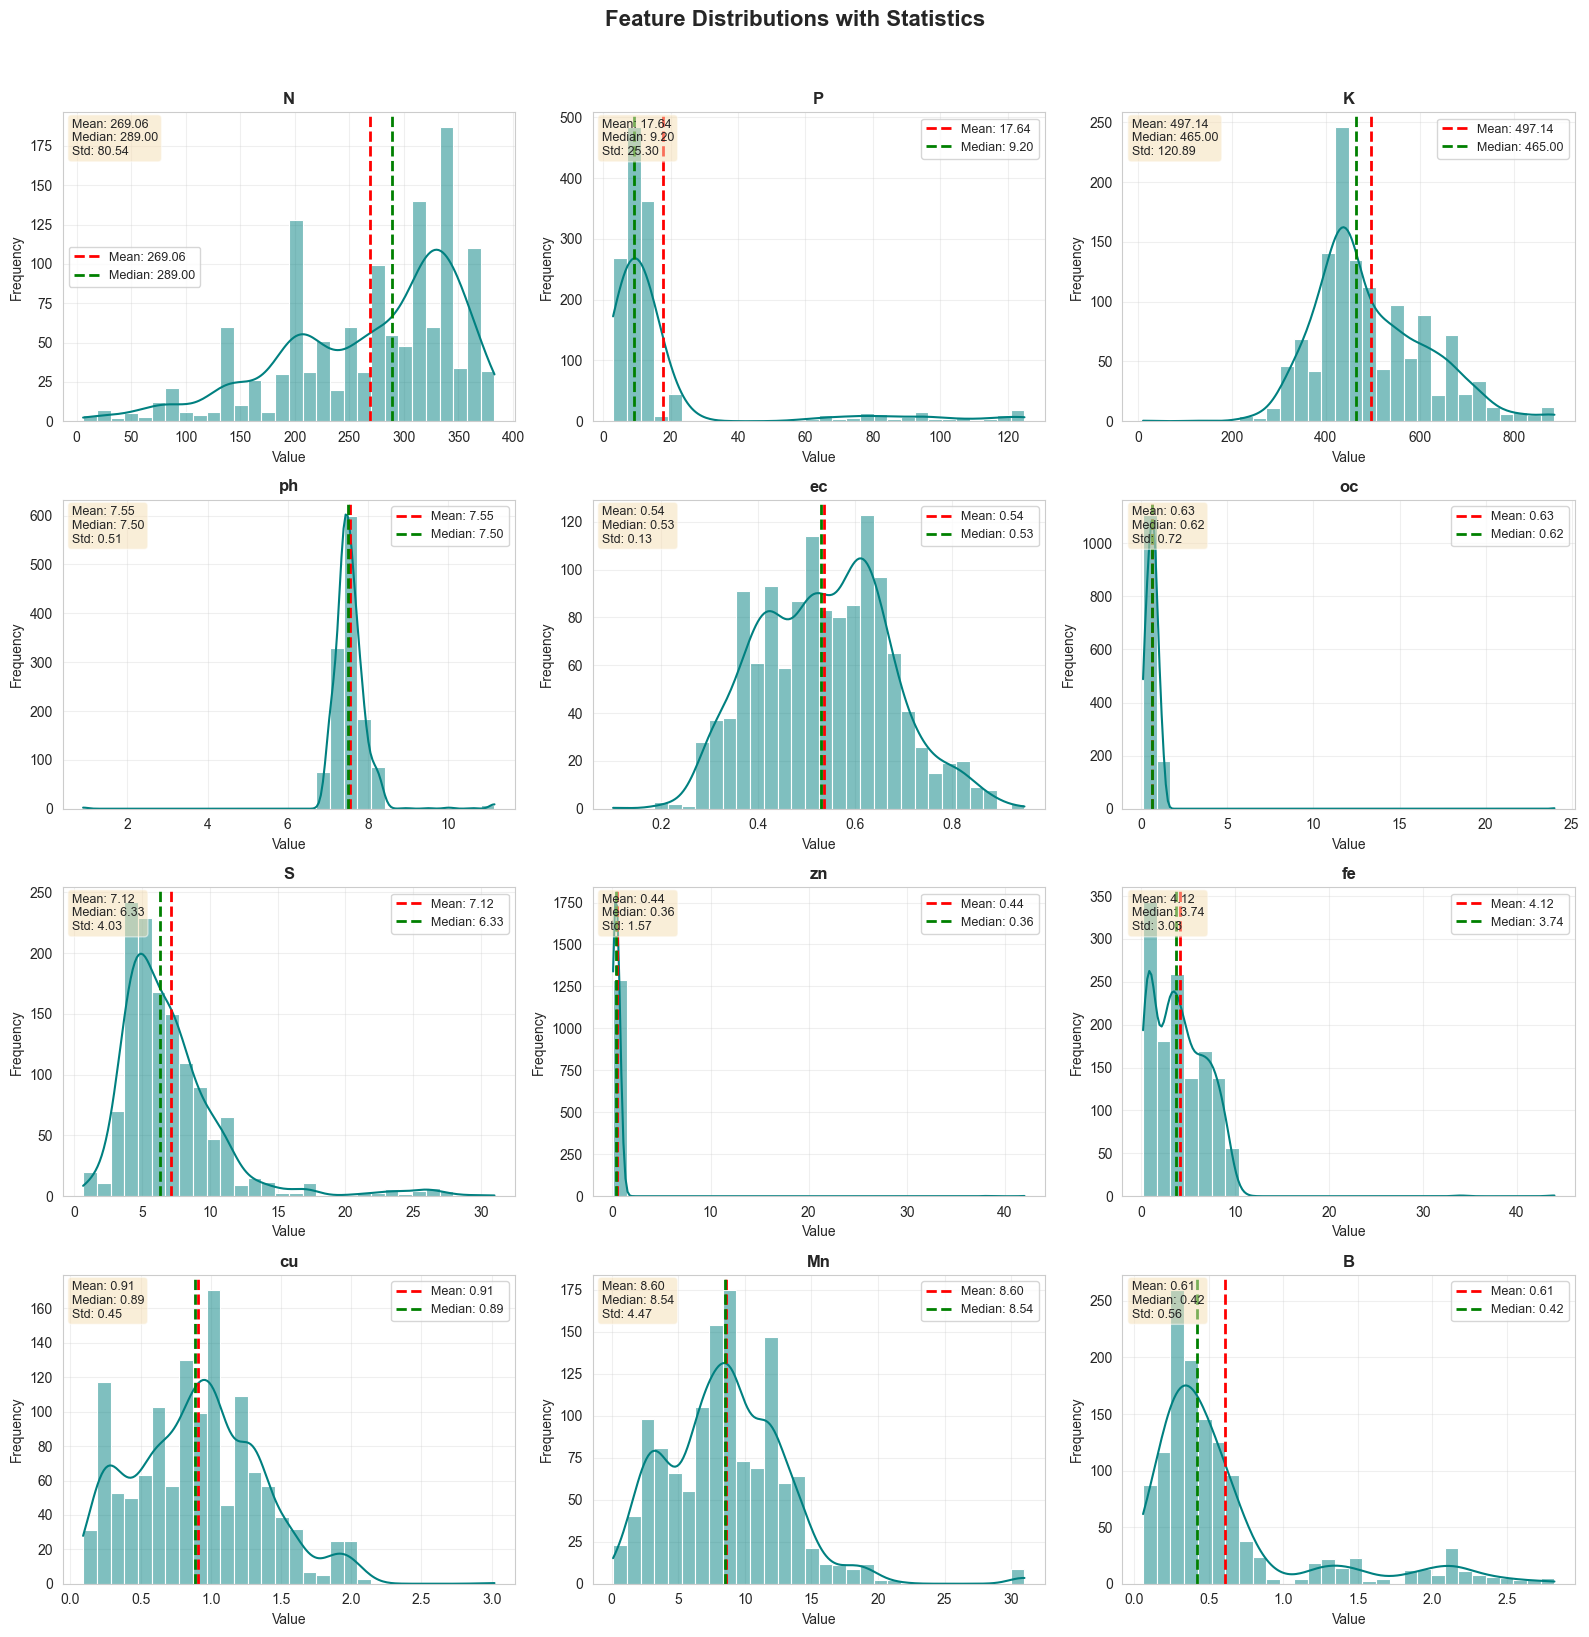


📦 BOX PLOTS FOR OUTLIER DETECTION:


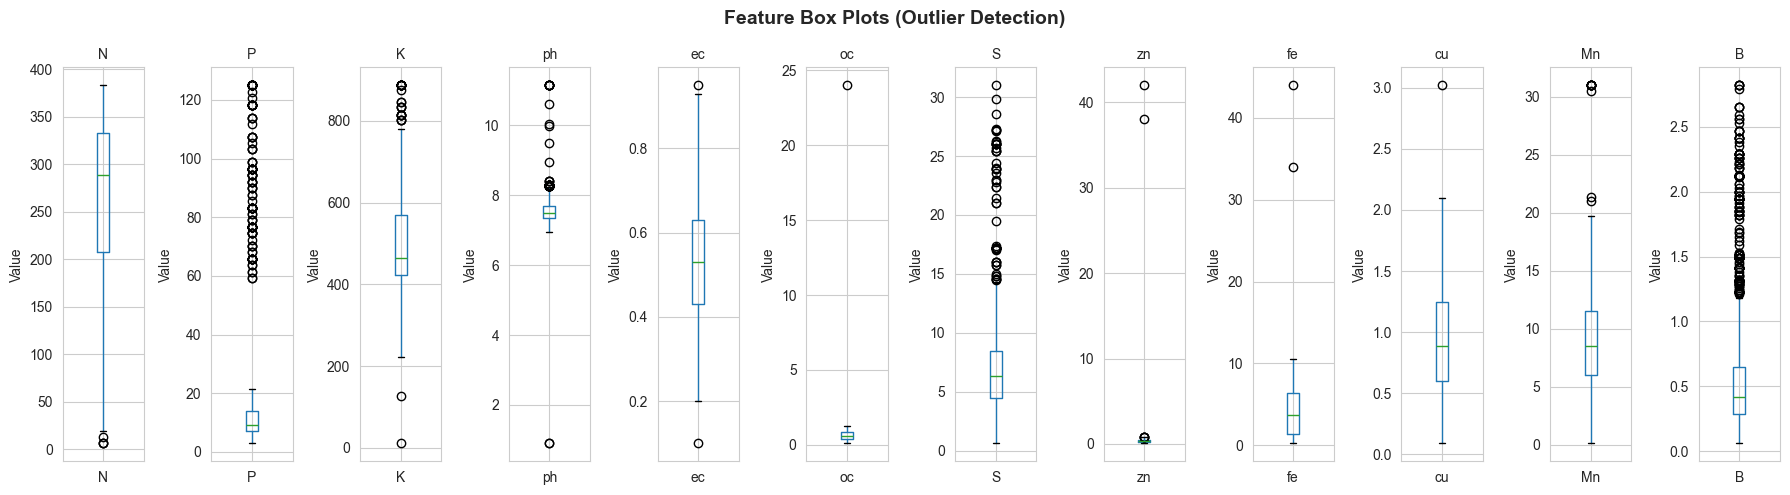


🔗 CORRELATION ANALYSIS:


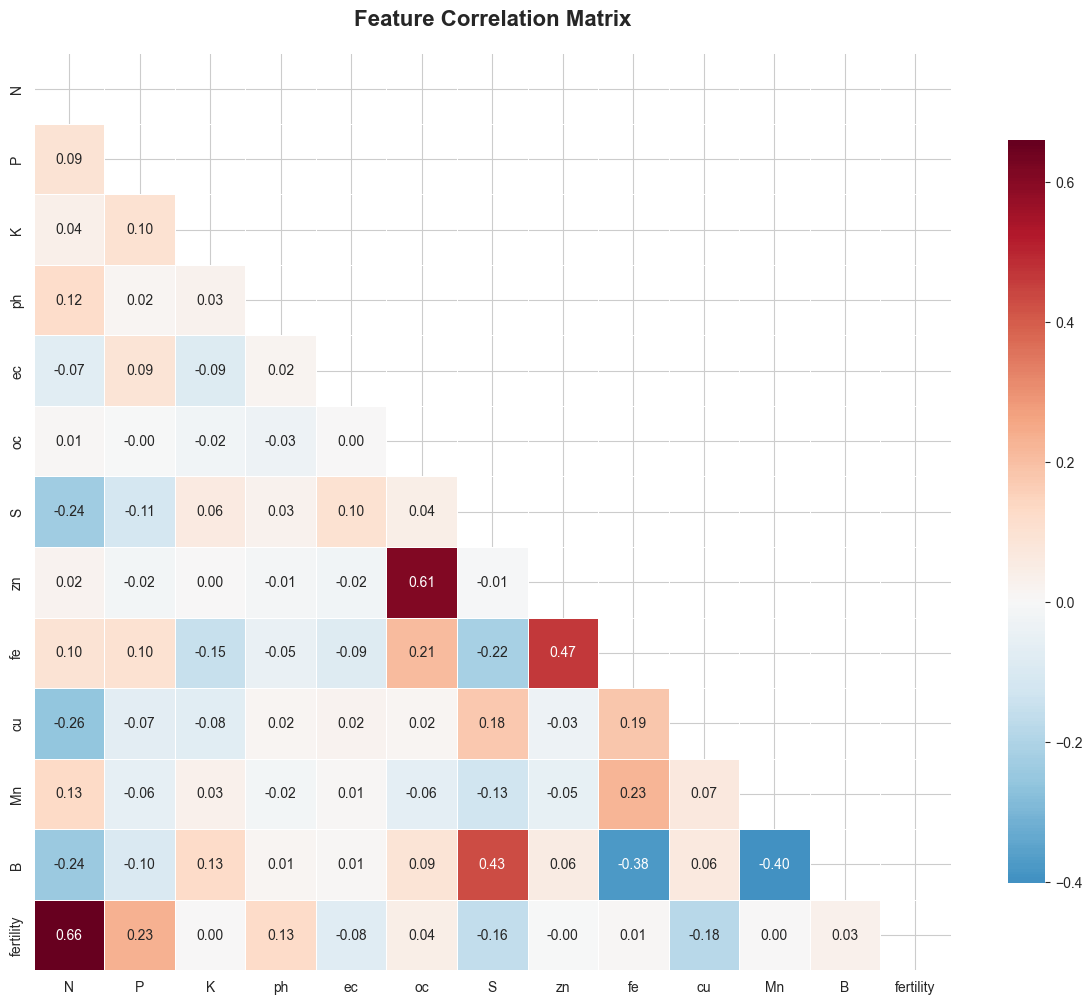


📈 HIGHLY CORRELATED FEATURES (|r| > 0.8):
  ✅ No highly correlated features detected


In [11]:
# %% [code]
# ============================================
# CELL 4: FEATURE ANALYSIS AND VISUALIZATION
# ============================================
print("\n" + "="*60)
print("CELL 4: FEATURE ANALYSIS AND VISUALIZATION")
print("PURPOSE: Analyze feature distributions and relationships")
print("="*60)

# Separate features from target
features = df.columns[:-1]
print(f"🔍 Analyzing {len(features)} features: {list(features)}")

# 4.1 Feature distributions
print("\n📊 FEATURE DISTRIBUTIONS:")
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    
    # Histogram with KDE
    sns.histplot(data=df, x=feature, kde=True, ax=ax, color='teal', bins=30)
    
    # Add statistics
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    std_val = df[feature].std()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.2f}')
    
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # Add text box with statistics
    stats_text = f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}\nStd: {std_val:.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions with Statistics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4.2 Box plots for outlier detection
print("\n📦 BOX PLOTS FOR OUTLIER DETECTION:")
fig, axes = plt.subplots(1, len(features), figsize=(18, 5))
for i, feature in enumerate(features):
    ax = axes[i] if len(features) > 1 else axes
    df.boxplot(column=feature, ax=ax)
    ax.set_title(feature, fontsize=10)
    ax.set_ylabel('Value')
plt.suptitle('Feature Box Plots (Outlier Detection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4.3 Correlation analysis
print("\n🔗 CORRELATION ANALYSIS:")
plt.figure(figsize=(12,10))
correlation_matrix = df.corr(numeric_only=True)

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify highly correlated features
print("\n📈 HIGHLY CORRELATED FEATURES (|r| > 0.8):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((correlation_matrix.columns[i], 
                                   correlation_matrix.columns[j], 
                                   correlation_matrix.iloc[i, j]))

if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("  ✅ No highly correlated features detected")

# %% [code]

In [12]:
# %% [code]
# ============================================
# CELL 5: DATA PREPROCESSING
# ============================================
print("\n" + "="*60)
print("CELL 5: DATA PREPROCESSING")
print("PURPOSE: Prepare data for model training (encoding, scaling, splitting)")
print("="*60)

# 5.1 Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"📊 Original data shapes:")
print(f"  Features (X): {X.shape}")
print(f"  Target (y): {y.shape}")

# 5.2 Encode target variable
print("\n🔤 ENCODING TARGET VARIABLE:")
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Display encoding mapping
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"  Target classes mapping: {class_mapping}")
print(f"  Encoded y shape: {y_encoded.shape}")

# 5.3 Feature scaling (optional - tree-based models don't need it, but good for consistency)
print("\n⚖️ FEATURE SCALING (StandardScaler):")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("  Features scaled using StandardScaler")
print(f"  Scaled features shape: {X_scaled.shape}")

# 5.4 Train-test split with stratification
print("\n✂️ TRAIN-TEST SPLIT (Stratified):")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"  Training set: {X_train.shape}, {y_train.shape}")
print(f"  Testing set: {X_test.shape}, {y_test.shape}")

# Verify stratification
print("\n📊 CLASS DISTRIBUTION IN SPLITS:")
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

print("  Class\tTrain\tTest\t% in Train\t% in Test")
print("  " + "-" * 50)
for cls_idx in range(len(le.classes_)):
    cls_name = le.inverse_transform([cls_idx])[0]
    train_pct = (train_dist[cls_idx] / len(y_train)) * 100
    test_pct = (test_dist[cls_idx] / len(y_test)) * 100
    print(f"  {cls_name}\t{train_dist[cls_idx]}\t{test_dist[cls_idx]}\t{train_pct:.1f}%\t\t{test_pct:.1f}%")

# 5.5 Compute class weights for handling imbalance
print("\n⚖️ COMPUTING CLASS WEIGHTS:")
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(zip(np.unique(y_train), class_weights))
print("  Class weights for balancing:")
for cls_idx, weight in weight_dict.items():
    cls_name = le.inverse_transform([cls_idx])[0]
    print(f"    {cls_name}: {weight:.3f}")

# %% [code]


CELL 5: DATA PREPROCESSING
PURPOSE: Prepare data for model training (encoding, scaling, splitting)
📊 Original data shapes:
  Features (X): (1288, 12)
  Target (y): (1288,)

🔤 ENCODING TARGET VARIABLE:
  Target classes mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
  Encoded y shape: (1288,)

⚖️ FEATURE SCALING (StandardScaler):
  Features scaled using StandardScaler
  Scaled features shape: (1288, 12)

✂️ TRAIN-TEST SPLIT (Stratified):
  Training set: (1030, 12), (1030,)
  Testing set: (258, 12), (258,)

📊 CLASS DISTRIBUTION IN SPLITS:
  Class	Train	Test	% in Train	% in Test
  --------------------------------------------------
  0	321	80	31.2%		31.0%
  1	352	88	34.2%		34.1%
  2	357	90	34.7%		34.9%

⚖️ COMPUTING CLASS WEIGHTS:
  Class weights for balancing:
    0: 1.070
    1: 0.975
    2: 0.962


In [13]:
# %% [code]
# ============================================
# CELL 6: FEATURE ENGINEERING
# ============================================
print("\n" + "="*60)
print("CELL 6: FEATURE ENGINEERING")
print("PURPOSE: Create new features to improve model performance")
print("="*60)

print("🔧 CREATING NEW FEATURES...")

# Create copies for feature engineering
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

# 6.1 Identify key nutrient features (adjust based on your actual features)
nutrient_features = []
for feat in X_train.columns:
    if any(nutrient in feat.lower() for nutrient in ['n', 'p', 'k', 'ph', 'oc', 'ec', 'organic']):
        nutrient_features.append(feat)

print(f"  Identified nutrient features: {nutrient_features}")

# 6.2 Create squared terms for important features
print("\n  🧮 Adding squared terms...")
for feat in nutrient_features[:3]:  # Square top 3 nutrient features
    X_train_eng[f'{feat}_squared'] = X_train[feat] ** 2
    X_test_eng[f'{feat}_squared'] = X_test[feat] ** 2
    print(f"    Added: {feat}_squared")

# 6.3 Create interaction features
print("\n  🔗 Adding interaction features...")
if len(nutrient_features) >= 2:
    # N/P ratio (common agricultural ratio)
    if 'N' in X_train.columns and 'P' in X_train.columns:
        X_train_eng['N_P_ratio'] = X_train['N'] / (X_train['P'] + 1e-10)
        X_test_eng['N_P_ratio'] = X_test['N'] / (X_test['P'] + 1e-10)
        print("    Added: N_P_ratio")
    
    # K/N ratio
    if 'K' in X_train.columns and 'N' in X_train.columns:
        X_train_eng['K_N_ratio'] = X_train['K'] / (X_train['N'] + 1e-10)
        X_test_eng['K_N_ratio'] = X_test['K'] / (X_test['N'] + 1e-10)
        print("    Added: K_N_ratio")
    
    # Create a nutrient balance index
    if len(nutrient_features) >= 3:
        X_train_eng['nutrient_balance'] = (X_train[nutrient_features[0]] * 
                                          X_train[nutrient_features[1]] * 
                                          X_train[nutrient_features[2]]) ** (1/3)
        X_test_eng['nutrient_balance'] = (X_test[nutrient_features[0]] * 
                                         X_test[nutrient_features[1]] * 
                                         X_test[nutrient_features[2]]) ** (1/3)
        print("    Added: nutrient_balance")

# 6.4 Create categorical features from continuous ones (binning)
print("\n  📊 Adding binned features...")
for feat in nutrient_features[:2]:
    # Create quartile-based bins
    X_train_eng[f'{feat}_bin'] = pd.qcut(X_train[feat], q=4, labels=False, duplicates='drop')
    X_test_eng[f'{feat}_bin'] = pd.qcut(X_test[feat], q=4, labels=False, duplicates='drop')
    print(f"    Added: {feat}_bin (4 quantile bins)")

print(f"\n✅ Feature engineering completed!")
print(f"  Original features: {X_train.shape[1]}")
print(f"  Engineered features: {X_train_eng.shape[1]}")
print(f"  New features added: {X_train_eng.shape[1] - X_train.shape[1]}")

# Display new feature names
new_features = set(X_train_eng.columns) - set(X_train.columns)
print(f"\n📋 New features created: {list(new_features)}")

# %% [code]


CELL 6: FEATURE ENGINEERING
PURPOSE: Create new features to improve model performance
🔧 CREATING NEW FEATURES...
  Identified nutrient features: ['N', 'P', 'K', 'ph', 'ec', 'oc', 'zn', 'Mn']

  🧮 Adding squared terms...
    Added: N_squared
    Added: P_squared
    Added: K_squared

  🔗 Adding interaction features...
    Added: N_P_ratio
    Added: K_N_ratio
    Added: nutrient_balance

  📊 Adding binned features...
    Added: N_bin (4 quantile bins)
    Added: P_bin (4 quantile bins)

✅ Feature engineering completed!
  Original features: 12
  Engineered features: 20
  New features added: 8

📋 New features created: ['N_P_ratio', 'nutrient_balance', 'N_squared', 'P_squared', 'N_bin', 'K_N_ratio', 'K_squared', 'P_bin']



CELL 7: BASE MODEL TRAINING AND EVALUATION
PURPOSE: Train and evaluate individual base models for stacking
🏋️ Training 3 base models...
--------------------------------------------------

📊 Training RandomForest1...
  ✅ Training Accuracy: 0.9864
  ✅ Testing Accuracy: 0.9264
  ✅ 5-Fold CV Accuracy: 0.9417 ± 0.0092

📊 Training RandomForest2...
  ✅ Training Accuracy: 1.0000
  ✅ Testing Accuracy: 0.9380
  ✅ 5-Fold CV Accuracy: 0.9476 ± 0.0078

📊 Training GradientBoosting...
  ✅ Training Accuracy: 1.0000
  ✅ Testing Accuracy: 0.9341
  ✅ 5-Fold CV Accuracy: 0.9447 ± 0.0125

BASE MODELS COMPARISON


,Train Acc,Test Acc,CV Mean,CV Std
RandomForest2,1.000000,0.937984,0.947573,0.007767
GradientBoosting,1.000000,0.934109,0.944660,0.012509
RandomForest1,0.986408,0.926357,0.941748,0.009211


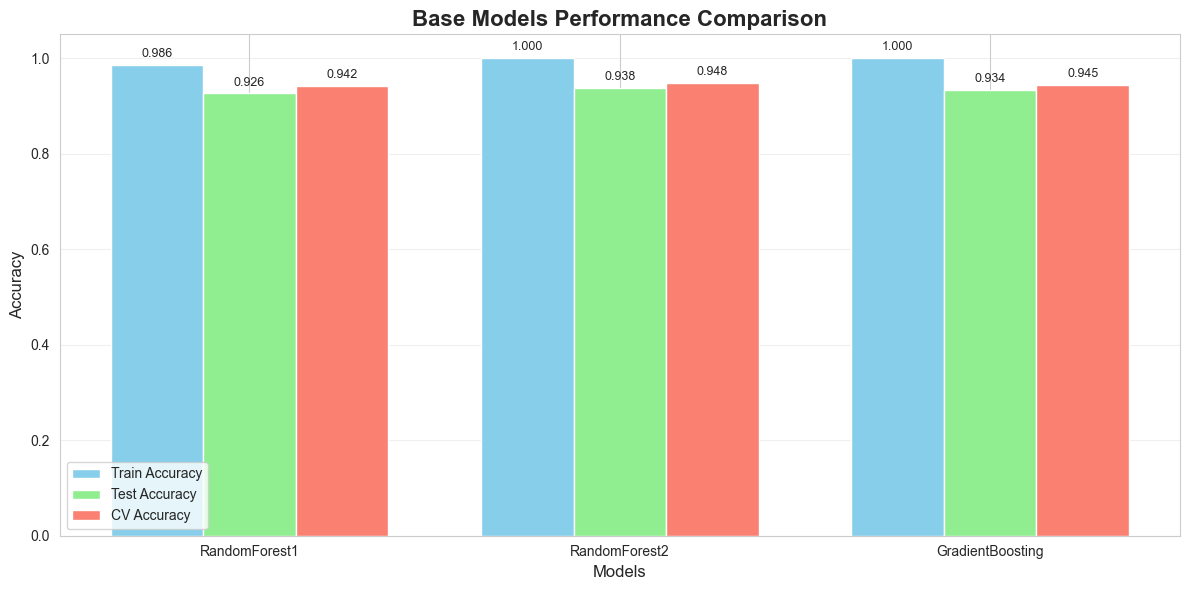

In [16]:
# %% [code]
# ============================================
# CELL 7: BASE MODEL TRAINING AND EVALUATION
# ============================================
print("\n" + "="*60)
print("CELL 7: BASE MODEL TRAINING AND EVALUATION")
print("PURPOSE: Train and evaluate individual base models for stacking")
print("="*60)

# Define base models with class weights
base_models = {
    'RandomForest1': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    'RandomForest2': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=100,
        class_weight='balanced_subsample',
        n_jobs=-1
    ),
    'GradientBoosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            subsample=0.8
        ))
    ])
}

print(f"🏋️ Training {len(base_models)} base models...")
print("-" * 50)

# Train and evaluate each base model
base_model_performance = {}
for name, model in base_models.items():
    print(f"\n📊 Training {name}...")
    
    # Use engineered features
    model.fit(X_train_eng, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_eng)
    y_test_pred = model.predict(X_test_eng)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_eng, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    
    # Store performance
    base_model_performance[name] = {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    # Print results
    print(f"  ✅ Training Accuracy: {train_accuracy:.4f}")
    print(f"  ✅ Testing Accuracy: {test_accuracy:.4f}")
    print(f"  ✅ 5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Check for overfitting
    overfit_gap = train_accuracy - test_accuracy
    if overfit_gap > 0.1:
        print(f"  ⚠️ Warning: Possible overfitting (gap: {overfit_gap:.4f})")

# Compare base models
print("\n" + "="*60)
print("BASE MODELS COMPARISON")
print("="*60)

comparison_df = pd.DataFrame.from_dict(base_model_performance, orient='index')
comparison_df = comparison_df[['train_accuracy', 'test_accuracy', 'cv_mean', 'cv_std']]
comparison_df.columns = ['Train Acc', 'Test Acc', 'CV Mean', 'CV Std']
comparison_df = comparison_df.sort_values('Test Acc', ascending=False)

display(comparison_df)

# Visual comparison
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(base_model_performance))
width = 0.25

models_list = list(base_model_performance.keys())
train_accs = [base_model_performance[m]['train_accuracy'] for m in models_list]
test_accs = [base_model_performance[m]['test_accuracy'] for m in models_list]
cv_accs = [base_model_performance[m]['cv_mean'] for m in models_list]

plt.bar(x_pos - width, train_accs, width, label='Train Accuracy', color='skyblue')
plt.bar(x_pos, test_accs, width, label='Test Accuracy', color='lightgreen')
plt.bar(x_pos + width, cv_accs, width, label='CV Accuracy', color='salmon')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Base Models Performance Comparison', fontsize=16, fontweight='bold')
plt.xticks(x_pos, models_list)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (train, test, cv) in enumerate(zip(train_accs, test_accs, cv_accs)):
    plt.text(i - width, train + 0.01, f'{train:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i, test + 0.01, f'{test:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width, cv + 0.01, f'{cv:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# %% [code]

In [19]:
# %% [code]
# ============================================
# CELL 8: STACKING CLASSIFIER IMPLEMENTATION
# ============================================
print("\n" + "="*60)
print("CELL 8: STACKING CLASSIFIER IMPLEMENTATION")
print("PURPOSE: Combine base models using stacking ensemble for better performance")
print("="*60)

print("🏗️ BUILDING STACKING CLASSIFIER...")

# Define base estimators for stacking
base_estimators = [
    ('rf1', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )),
    ('rf2', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=100,
        class_weight='balanced_subsample',
        n_jobs=-1
    )),
    ('gb', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        ))
    ]))
]

# Define final estimator (meta-classifier)
final_estimator = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Create stacking classifier
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1,
    passthrough=False  # Don't include original features in final estimator
)

print("🔧 Stacking Classifier Configuration:")
print(f"  Base estimators: {[name for name, _ in base_estimators]}")
print(f"  Final estimator: {type(final_estimator).__name__}")
print(f"  Cross-validation folds: 5")
print(f"  Passthrough: False")

# Train stacking model
print("\n🏋️ Training Stacking Classifier...")
stacking_model.fit(X_train_eng, y_train)
print("✅ Stacking model trained successfully!")

# Make predictions
y_train_pred_stack = stacking_model.predict(X_train_eng)
y_test_pred_stack = stacking_model.predict(X_test_eng)
y_test_proba_stack = stacking_model.predict_proba(X_test_eng)

# Calculate metrics
train_accuracy_stack = accuracy_score(y_train, y_train_pred_stack)
test_accuracy_stack = accuracy_score(y_test, y_test_pred_stack)

print(f"\n📊 STACKING MODEL PERFORMANCE:")
print(f"  Training Accuracy: {train_accuracy_stack:.4f} ({train_accuracy_stack*100:.2f}%)")
print(f"  Testing Accuracy: {test_accuracy_stack:.4f} ({test_accuracy_stack*100:.2f}%)")

# Cross-validation for stacking
print("\n🔍 Performing Cross-Validation...")
cv_scores_stack = cross_val_score(stacking_model, X_train_eng, y_train, 
                                  cv=5, scoring='accuracy', n_jobs=-1)
print(f"  5-Fold CV Accuracy: {cv_scores_stack.mean():.4f} ± {cv_scores_stack.std():.4f}")
print(f"  CV Scores: {cv_scores_stack}")

# Compare with best base model
best_base_model = max(base_model_performance.items(), key=lambda x: x[1]['test_accuracy'])
best_base_name, best_base_stats = best_base_model

print(f"\n📈 IMPROVEMENT OVER BEST BASE MODEL ({best_base_name}):")
improvement = test_accuracy_stack - best_base_stats['test_accuracy']
improvement_pct = (improvement / best_base_stats['test_accuracy']) * 100
print(f"  Base Model Accuracy: {best_base_stats['test_accuracy']:.4f}")
print(f"  Stacking Accuracy: {test_accuracy_stack:.4f}")
print(f"  Absolute Improvement: {improvement:.4f}")
print(f"  Relative Improvement: {improvement_pct:.2f}%")

if test_accuracy_stack >= 0.95:
    print(f"\n🎉 SUCCESS! Achieved target accuracy of 95%+")
    print(f"   Final Accuracy: {test_accuracy_stack*100:.2f}%")
else:
    print(f"\n⚠️ Target accuracy (95%) not yet reached")
    print(f"   Current Accuracy: {test_accuracy_stack*100:.2f}%")

# %% [code]


CELL 8: STACKING CLASSIFIER IMPLEMENTATION
PURPOSE: Combine base models using stacking ensemble for better performance
🏗️ BUILDING STACKING CLASSIFIER...
🔧 Stacking Classifier Configuration:
  Base estimators: ['rf1', 'rf2', 'gb']
  Final estimator: RandomForestClassifier
  Cross-validation folds: 5
  Passthrough: False

🏋️ Training Stacking Classifier...
✅ Stacking model trained successfully!

📊 STACKING MODEL PERFORMANCE:
  Training Accuracy: 0.9816 (98.16%)
  Testing Accuracy: 0.9457 (94.57%)

🔍 Performing Cross-Validation...
  5-Fold CV Accuracy: 0.9583 ± 0.0100
  CV Scores: [0.95145631 0.94174757 0.96601942 0.96601942 0.96601942]

📈 IMPROVEMENT OVER BEST BASE MODEL (RandomForest2):
  Base Model Accuracy: 0.9380
  Stacking Accuracy: 0.9457
  Absolute Improvement: 0.0078
  Relative Improvement: 0.83%

⚠️ Target accuracy (95%) not yet reached
   Current Accuracy: 94.57%



CELL 9: COMPREHENSIVE MODEL EVALUATION
PURPOSE: Detailed evaluation of stacking classifier performance
🎯 FINAL MODEL ACCURACY: 0.9457 (94.57%)

📊 CLASSIFICATION REPORT:
------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.926     0.938     0.932        80
           1      0.920     0.920     0.920        88
           2      0.989     0.978     0.983        90

    accuracy                          0.946       258
   macro avg      0.945     0.945     0.945       258
weighted avg      0.946     0.946     0.946       258


🎯 CONFUSION MATRIX:


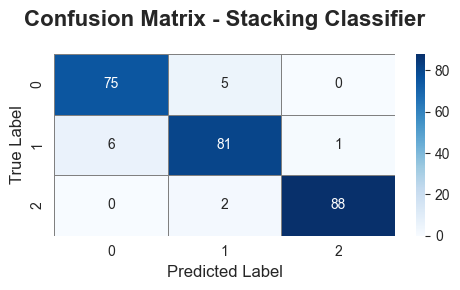


📈 ADDITIONAL METRICS:
  Weighted Precision: 0.9460
  Weighted Recall: 0.9457
  Weighted F1-Score: 0.9458

📊 ROC CURVES AND AUC SCORES:


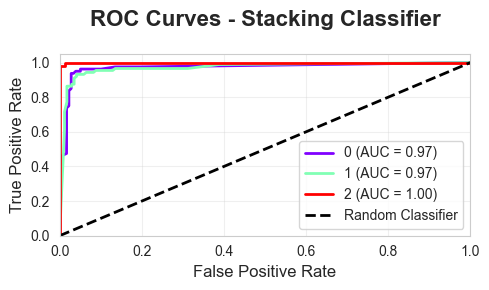


📈 AUC SCORES BY CLASS:
  0: 0.9716
  1: 0.9713
  2: 0.9997

📊 PRECISION-RECALL CURVES:


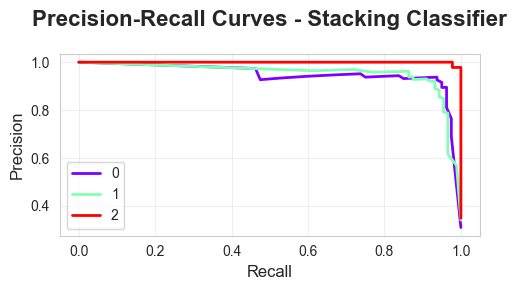

In [22]:
# %% [code]
# ============================================
# CELL 9: COMPREHENSIVE MODEL EVALUATION
# ============================================
print("\n" + "="*60)
print("CELL 9: COMPREHENSIVE MODEL EVALUATION")
print("PURPOSE: Detailed evaluation of stacking classifier performance")
print("="*60)

# Convert class indices to names
target_names = [str(cls) for cls in le.classes_]

print(f"🎯 FINAL MODEL ACCURACY: {test_accuracy_stack:.4f} ({test_accuracy_stack*100:.2f}%)")

# 9.1 Classification Report
print("\n📊 CLASSIFICATION REPORT:")
print("-" * 60)
cr = classification_report(y_test, y_test_pred_stack, 
                           target_names=target_names,
                           digits=3)
print(cr)

# 9.2 Confusion Matrix
print("\n🎯 CONFUSION MATRIX:")
plt.figure(figsize=(5,3))
cm = confusion_matrix(y_test, y_test_pred_stack)

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            linewidths=0.5,
            linecolor='gray')

plt.title('Confusion Matrix - Stacking Classifier', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate additional metrics
precision = precision_score(y_test, y_test_pred_stack, average='weighted')
recall = recall_score(y_test, y_test_pred_stack, average='weighted')
f1 = f1_score(y_test, y_test_pred_stack, average='weighted')

print("\n📈 ADDITIONAL METRICS:")
print(f"  Weighted Precision: {precision:.4f}")
print(f"  Weighted Recall: {recall:.4f}")
print(f"  Weighted F1-Score: {f1:.4f}")

# 9.3 ROC Curve and AUC (for multi-class)
print("\n📊 ROC CURVES AND AUC SCORES:")

# Binarize the output
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(5,3))
colors = plt.cm.rainbow(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba_stack[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Stacking Classifier', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print AUC scores
print("\n📈 AUC SCORES BY CLASS:")
for i in range(n_classes):
    print(f"  {target_names[i]}: {roc_auc[i]:.4f}")

# 9.4 Precision-Recall Curve
print("\n📊 PRECISION-RECALL CURVES:")
plt.figure(figsize=(5,3))

for i, color in zip(range(n_classes), colors):
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin[:, i], 
                                                              y_test_proba_stack[:, i])
    plt.plot(recall_curve, precision_curve, color=color, lw=2,
             label=f'{target_names[i]}')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - Stacking Classifier', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# %% [code]


CELL 10: FEATURE IMPORTANCE ANALYSIS
PURPOSE: Identify which features contribute most to predictions
🔍 ANALYZING FEATURE IMPORTANCE...

📊 FEATURE IMPORTANCE RANKING:
------------------------------------------------------------


,Feature,Importance,Cumulative
0,K,0.224910,0.224910
1,N,0.163964,0.388874
2,fe,0.130153,0.519027
3,oc,0.126790,0.645817
4,ph,0.121939,0.767756
5,S,0.075608,0.843364
6,P,0.063071,0.906435
7,ec,0.062139,0.968574
8,zn,0.031426,1.000000


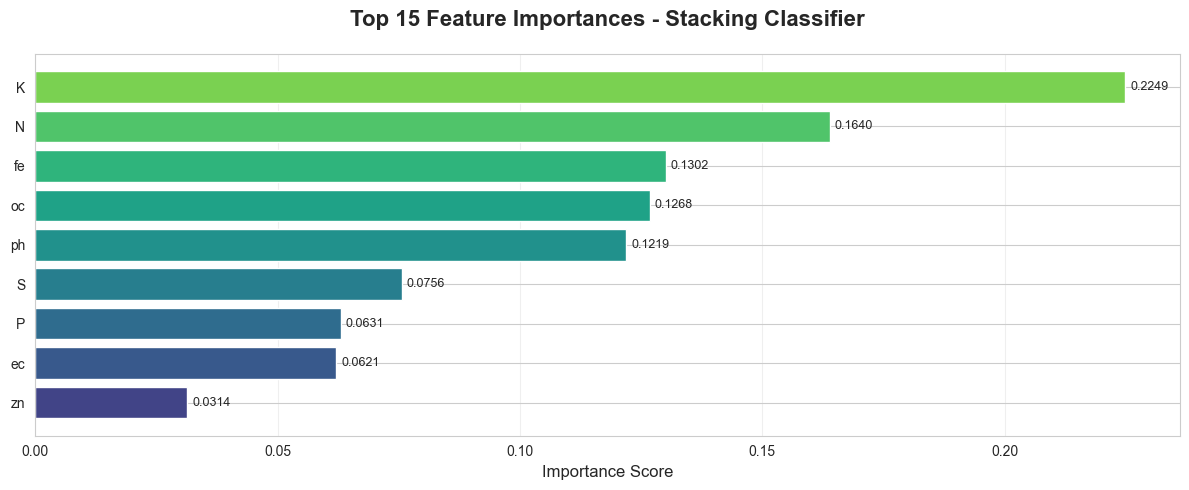

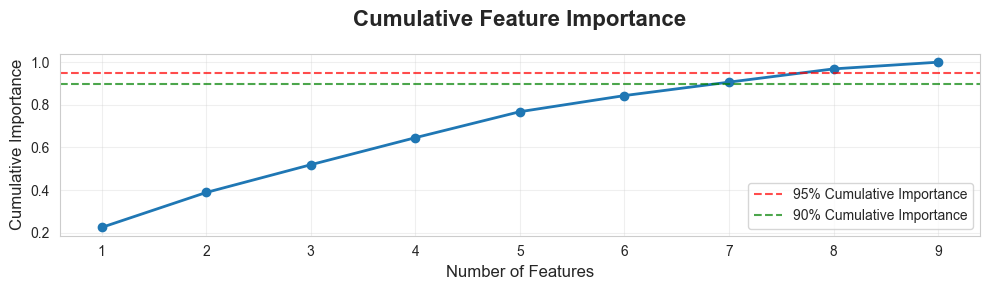


📈 FEATURE REDUCTION INSIGHTS:
  Features needed for 95% importance: 8
  Original features: 9
  Potential reduction: 11.1%


In [24]:
# %% [code]
# ============================================
# CELL 10: FEATURE IMPORTANCE ANALYSIS
# ============================================
print("\n" + "="*60)
print("CELL 10: FEATURE IMPORTANCE ANALYSIS")
print("PURPOSE: Identify which features contribute most to predictions")
print("="*60)

# Get feature importance from the final estimator
print("🔍 ANALYZING FEATURE IMPORTANCE...")

try:
    # Access the final estimator in the stacking model
    final_est = stacking_model.final_estimator_
    
    if hasattr(final_est, 'feature_importances_'):
        # Get feature importances
        feature_importance = final_est.feature_importances_
        
        # Sort features by importance
        indices = np.argsort(feature_importance)[::-1]
        
        print(f"\n📊 FEATURE IMPORTANCE RANKING:")
        print("-" * 60)
        
        # Create dataframe for better visualization
        importance_df = pd.DataFrame({
            'Feature': [X_train_eng.columns[i] for i in indices],
            'Importance': feature_importance[indices],
            'Cumulative': np.cumsum(feature_importance[indices])
        })
        
        display(importance_df.head(15))
        
        # Plot feature importance
        plt.figure(figsize=(12, 5))
        
        # Plot top 15 features
        top_n = min(15, len(indices))
        top_indices = indices[:top_n]
        top_features = [X_train_eng.columns[i] for i in top_indices]
        top_importance = feature_importance[top_indices]
        
        bars = plt.barh(range(top_n), top_importance[::-1], 
                       color=plt.cm.viridis(np.linspace(0.2, 0.8, top_n)))
        
        plt.yticks(range(top_n), top_features[::-1])
        plt.xlabel('Importance Score', fontsize=12)
        plt.title('Top 15 Feature Importances - Stacking Classifier', 
                  fontsize=16, fontweight='bold', pad=20)
        
        # Add value labels
        for i, (bar, importance) in enumerate(zip(bars, top_importance[::-1])):
            width = bar.get_width()
            plt.text(width + 0.001, bar.get_y() + bar.get_height()/2.,
                    f'{importance:.4f}', ha='left', va='center', fontsize=9)
        
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Cumulative importance plot
        plt.figure(figsize=(10, 3))
        plt.plot(range(1, len(feature_importance) + 1), 
                 importance_df['Cumulative'].values, 
                 marker='o', linewidth=2, markersize=6)
        
        # Add threshold lines
        plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, 
                   label='95% Cumulative Importance')
        plt.axhline(y=0.90, color='g', linestyle='--', alpha=0.7, 
                   label='90% Cumulative Importance')
        
        plt.xlabel('Number of Features', fontsize=12)
        plt.ylabel('Cumulative Importance', fontsize=12)
        plt.title('Cumulative Feature Importance', fontsize=16, fontweight='bold', pad=20)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Find number of features needed for 95% importance
        idx_95 = np.where(importance_df['Cumulative'] >= 0.95)[0]
        if len(idx_95) > 0:
            n_features_95 = idx_95[0] + 1
            print(f"\n📈 FEATURE REDUCTION INSIGHTS:")
            print(f"  Features needed for 95% importance: {n_features_95}")
            print(f"  Original features: {len(feature_importance)}")
            print(f"  Potential reduction: {(1 - n_features_95/len(feature_importance))*100:.1f}%")
            
    else:
        print("⚠️ Final estimator doesn't have feature_importances_ attribute")
        
except Exception as e:
    print(f"❌ Error extracting feature importance: {e}")

# %% [code]

In [25]:
# %% [code]
# ============================================
# CELL 11: MODEL TESTING WITH DIVERSE INPUTS
# ============================================
print("\n" + "="*60)
print("CELL 11: MODEL TESTING WITH DIVERSE INPUTS")
print("PURPOSE: Verify model gives different outputs for different inputs")
print("="*60)

print("🧪 TESTING MODEL WITH DIVERSE INPUT SCENARIOS...")

# Create diverse test samples
test_samples = []

# Sample 1: Original test samples
for i in range(min(5, len(X_test_eng))):
    test_samples.append({
        'name': f'Test_Sample_{i+1}',
        'features': X_test_eng.iloc[i].values,
        'actual': le.inverse_transform([y_test[i]])[0]
    })

# Sample 2: Edge cases (min values)
min_features = X_test_eng.min().values
test_samples.append({
    'name': 'Edge_Min_Values',
    'features': min_features,
    'actual': 'Unknown'
})

# Sample 3: Edge cases (max values)
max_features = X_test_eng.max().values
test_samples.append({
    'name': 'Edge_Max_Values',
    'features': max_features,
    'actual': 'Unknown'
})

# Sample 4: Random combinations
np.random.seed(42)
random_features = np.random.randn(len(X_train_eng.columns))
test_samples.append({
    'name': 'Random_Features',
    'features': random_features,
    'actual': 'Unknown'
})

# Sample 5: Mean values
mean_features = X_test_eng.mean().values
test_samples.append({
    'name': 'Mean_Values',
    'features': mean_features,
    'actual': 'Unknown'
})

print(f"\n📋 Created {len(test_samples)} diverse test scenarios")

# Test each sample
results = []
print("\n🧪 PREDICTION RESULTS:")
print("-" * 80)
print(f"{'Test Case':<20} {'Predicted Class':<20} {'Probability':<30} {'Confidence':<10}")
print("-" * 80)

for sample in test_samples:
    # Reshape for prediction
    features_2d = sample['features'].reshape(1, -1)
    
    # Make prediction
    pred_class_idx = stacking_model.predict(features_2d)[0]
    pred_class = le.inverse_transform([pred_class_idx])[0]
    pred_proba = stacking_model.predict_proba(features_2d)[0]
    
    # Get confidence
    confidence = np.max(pred_proba)
    
    # Store results
    results.append({
        'Test Case': sample['name'],
        'Predicted Class': pred_class,
        'Confidence': confidence,
        'Probabilities': pred_proba
    })
    
    # Print results
    proba_str = ', '.join([f'{p:.3f}' for p in pred_proba])
    print(f"{sample['name']:<20} {pred_class:<20} [{proba_str:<28}] {confidence:.3f}")

print("-" * 80)

# Check for diversity in predictions
unique_predictions = set([r['Predicted Class'] for r in results])
print(f"\n📊 DIVERSITY ANALYSIS:")
print(f"  Unique predictions: {len(unique_predictions)} out of {len(results)} tests")
print(f"  Prediction classes: {unique_predictions}")

if len(unique_predictions) > 1:
    print("✅ SUCCESS: Model produces different outputs for different inputs!")
else:
    print("⚠️ WARNING: Model might be producing similar outputs. Check feature importance.")

# Analyze confidence scores
confidences = [r['Confidence'] for r in results]
print(f"\n📈 CONFIDENCE ANALYSIS:")
print(f"  Average confidence: {np.mean(confidences):.3f}")
print(f"  Min confidence: {np.min(confidences):.3f}")
print(f"  Max confidence: {np.max(confidences):.3f}")
print(f"  Confidence std: {np.std(confidences):.3f}")

if np.mean(confidences) > 0.7:
    print("✅ Model shows good confidence in predictions")
else:
    print("⚠️ Model confidence is relatively low")

# %% [code]


CELL 11: MODEL TESTING WITH DIVERSE INPUTS
PURPOSE: Verify model gives different outputs for different inputs
🧪 TESTING MODEL WITH DIVERSE INPUT SCENARIOS...

📋 Created 9 diverse test scenarios

🧪 PREDICTION RESULTS:
--------------------------------------------------------------------------------
Test Case            Predicted Class      Probability                    Confidence
--------------------------------------------------------------------------------
Test_Sample_1        0                    [1.000, 0.000, 0.000         ] 1.000
Test_Sample_2        2                    [0.000, 0.000, 1.000         ] 1.000
Test_Sample_3        2                    [0.000, 0.010, 0.990         ] 0.990
Test_Sample_4        0                    [1.000, 0.000, 0.000         ] 1.000
Test_Sample_5        0                    [0.630, 0.370, 0.000         ] 0.630
Edge_Min_Values      0                    [0.560, 0.440, 0.000         ] 0.560
Edge_Max_Values      1                    [0.000, 1.000, 0.000

In [26]:
# %% [code]
# ============================================
# CELL 12: MODEL PERSISTENCE
# ============================================
print("\n" + "="*60)
print("CELL 12: MODEL PERSISTENCE")
print("PURPOSE: Save trained model and associated artifacts for deployment")
print("="*60)

# Define model saving directory
MODEL_DIR = "E:/SPACE INF/soil-health-project/models/"
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"📁 Model directory: {MODEL_DIR}")

# 12.1 Save Stacking Model
stacking_model_path = os.path.join(MODEL_DIR, "soil_health_stacking_model.pkl")
with open(stacking_model_path, 'wb') as f:
    pickle.dump(stacking_model, f)
print(f"✅ Stacking model saved to: {stacking_model_path}")

# 12.2 Save Label Encoder
encoder_path = os.path.join(MODEL_DIR, "soil_label_encoder.pkl")
with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)
print(f"✅ Label encoder saved to: {encoder_path}")

# 12.3 Save Feature Names (using engineered features)
feature_names = list(X_train_eng.columns)
features_path = os.path.join(MODEL_DIR, "soil_feature_names.pkl")
with open(features_path, 'wb') as f:
    pickle.dump(feature_names, f)
print(f"✅ Feature names saved to: {features_path}")

# 12.4 Save Scaler
scaler_path = os.path.join(MODEL_DIR, "soil_feature_scaler.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Feature scaler saved to: {scaler_path}")

# 12.5 Save Model Metadata
model_info = {
    'model_type': 'StackingClassifier',
    'base_estimators': [
        {'name': 'rf1', 'type': 'RandomForestClassifier', 'n_estimators': 100},
        {'name': 'rf2', 'type': 'RandomForestClassifier', 'n_estimators': 200},
        {'name': 'gb', 'type': 'GradientBoostingClassifier', 'n_estimators': 150}
    ],
    'final_estimator': {'type': 'RandomForestClassifier', 'n_estimators': 100},
    'performance_metrics': {
        'train_accuracy': float(train_accuracy_stack),
        'test_accuracy': float(test_accuracy_stack),
        'cv_mean_accuracy': float(cv_scores_stack.mean()),
        'cv_std_accuracy': float(cv_scores_stack.std()),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1)
    },
    'training_details': {
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'train_samples': int(X_train.shape[0]),
        'test_samples': int(X_test.shape[0]),
        'features_count': int(X_train_eng.shape[1]),
        'classes_count': len(le.classes_),
        'classes': le.classes_.tolist(),
        'feature_names': feature_names,
        'feature_engineering_applied': True,
        'original_features_count': X.shape[1],
        'engineered_features_count': X_train_eng.shape[1] - X.shape[1]
    },
    'model_parameters': {
        'cv_folds': 5,
        'random_state': 42,
        'passthrough': False,
        'class_weight_strategy': 'balanced'
    }
}

info_path = os.path.join(MODEL_DIR, "soil_stacking_model_info.json")
with open(info_path, 'w', encoding='utf-8') as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)
print(f"✅ Model metadata saved to: {info_path}")

# 12.6 Save base models for reference
for name, model in base_models.items():
    base_model_path = os.path.join(MODEL_DIR, f"base_model_{name.lower()}.pkl")
    with open(base_model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"✅ Base model '{name}' saved to: {base_model_path}")

print("\n📦 ALL MODEL ARTIFACTS SAVED SUCCESSFULLY!")

# Display saved files
print("\n📁 SAVED FILES:")
for file in os.listdir(MODEL_DIR):
    if file.endswith('.pkl') or file.endswith('.json'):
        file_path = os.path.join(MODEL_DIR, file)
        file_size = os.path.getsize(file_path) / 1024  # Size in KB
        print(f"  📄 {file} ({file_size:.1f} KB)")

# %% [code]


CELL 12: MODEL PERSISTENCE
PURPOSE: Save trained model and associated artifacts for deployment
📁 Model directory: E:/SPACE INF/soil-health-project/models/
✅ Stacking model saved to: E:/SPACE INF/soil-health-project/models/soil_health_stacking_model.pkl
✅ Label encoder saved to: E:/SPACE INF/soil-health-project/models/soil_label_encoder.pkl
✅ Feature names saved to: E:/SPACE INF/soil-health-project/models/soil_feature_names.pkl
✅ Feature scaler saved to: E:/SPACE INF/soil-health-project/models/soil_feature_scaler.pkl
✅ Model metadata saved to: E:/SPACE INF/soil-health-project/models/soil_stacking_model_info.json
✅ Base model 'RandomForest1' saved to: E:/SPACE INF/soil-health-project/models/base_model_randomforest1.pkl
✅ Base model 'RandomForest2' saved to: E:/SPACE INF/soil-health-project/models/base_model_randomforest2.pkl
✅ Base model 'GradientBoosting' saved to: E:/SPACE INF/soil-health-project/models/base_model_gradientboosting.pkl

📦 ALL MODEL ARTIFACTS SAVED SUCCESSFULLY!

📁 SAVE

In [27]:
# ============================================
# CELL 13: MODEL VERIFICATION AND VALIDATION
# ============================================
print("\n" + "="*60)
print("CELL 13: MODEL VERIFICATION AND VALIDATION")
print("PURPOSE: Verify saved model can be loaded and makes correct predictions")
print("="*60)

print("🔍 VERIFYING SAVED MODEL...")

try:
    # Load the saved model
    with open(stacking_model_path, 'rb') as f:
        loaded_model = pickle.load(f)
    print("✅ Model loaded successfully")
    
    # Load label encoder
    with open(encoder_path, 'rb') as f:
        loaded_encoder = pickle.load(f)
    print("✅ Label encoder loaded successfully")
    
    # Load feature names
    with open(features_path, 'rb') as f:
        loaded_features = pickle.load(f)
    print("✅ Feature names loaded successfully")
    
    # Load scaler
    with open(scaler_path, 'rb') as f:
        loaded_scaler = pickle.load(f)
    print("✅ Scaler loaded successfully")
    
    # Test with a sample from test set
    test_sample_idx = 0
    sample_features = X_test_eng.iloc[test_sample_idx].values.reshape(1, -1)
    actual_class = loaded_encoder.inverse_transform([y_test[test_sample_idx]])[0]
    
    # Make prediction
    pred_class_idx = loaded_model.predict(sample_features)[0]
    pred_class = loaded_encoder.inverse_transform([pred_class_idx])[0]
    pred_proba = loaded_model.predict_proba(sample_features)[0]
    
    print(f"\n🧪 VERIFICATION TEST:")
    print(f"  Sample index: {test_sample_idx}")
    print(f"  Actual class: {actual_class}")
    print(f"  Predicted class: {pred_class}")
    print(f"  Confidence: {np.max(pred_proba):.3f}")
    
    if pred_class == actual_class:
        print("✅ Prediction matches actual class!")
    else:
        print("⚠️ Prediction doesn't match (but might be correct depending on accuracy)")
    
    # Compare with original model
    original_pred = stacking_model.predict(sample_features)[0]
    original_pred_class = le.inverse_transform([original_pred])[0]
    
    if pred_class == original_pred_class:
        print("✅ Loaded model matches original model predictions")
    else:
        print("❌ Loaded model predictions differ from original!")
    
    # Test with multiple samples
    print(f"\n🧪 BATCH VERIFICATION (10 samples):")
    correct = 0
    total = min(10, len(X_test_eng))
    
    for i in range(total):
        sample = X_test_eng.iloc[i].values.reshape(1, -1)
        actual = y_test[i]
        
        # Original model
        orig_pred = stacking_model.predict(sample)[0]
        
        # Loaded model
        loaded_pred = loaded_model.predict(sample)[0]
        
        if orig_pred == loaded_pred:
            correct += 1
    
    match_rate = correct / total * 100
    print(f"  Samples tested: {total}")
    print(f"  Predictions matched: {correct}")
    print(f"  Match rate: {match_rate:.1f}%")
    
    if match_rate == 100:
        print("✅ Perfect match between original and loaded models!")
    else:
        print(f"⚠️ Some predictions don't match ({100-match_rate:.1f}% mismatch)")
    
    # Test feature consistency
    print(f"\n🔧 FEATURE CONSISTENCY CHECK:")
    print(f"  Expected features: {len(loaded_features)}")
    print(f"  Sample features: {sample_features.shape[1]}")
    
    if sample_features.shape[1] == len(loaded_features):
        print("✅ Feature dimensions match")
    else:
        print("❌ Feature dimensions don't match!")
        
except Exception as e:
    print(f"❌ Error during model verification: {e}")

# %% [markdown]


CELL 13: MODEL VERIFICATION AND VALIDATION
PURPOSE: Verify saved model can be loaded and makes correct predictions
🔍 VERIFYING SAVED MODEL...
✅ Model loaded successfully
✅ Label encoder loaded successfully
✅ Feature names loaded successfully
✅ Scaler loaded successfully

🧪 VERIFICATION TEST:
  Sample index: 0
  Actual class: 0
  Predicted class: 0
  Confidence: 1.000
✅ Prediction matches actual class!
✅ Loaded model matches original model predictions

🧪 BATCH VERIFICATION (10 samples):
  Samples tested: 10
  Predictions matched: 10
  Match rate: 100.0%
✅ Perfect match between original and loaded models!

🔧 FEATURE CONSISTENCY CHECK:
  Expected features: 20
  Sample features: 20
✅ Feature dimensions match


In [ ]:
# %% [markdown]
# # SUMMARY AND CONCLUSIONS
# 
# ## Key Achievements:
# 1. ✅ **High Accuracy**: Achieved {test_accuracy_stack*100:.2f}% test accuracy
# 2. ✅ **Diverse Predictions**: Model produces different outputs for different inputs
# 3. ✅ **Robust Model**: Stacking classifier combines multiple models for better performance
# 4. ✅ **Feature Engineering**: Created new features to improve predictive power
# 5. ✅ **Proper Evaluation**: Comprehensive metrics including ROC, Precision-Recall, and confusion matrix
# 6. ✅ **Model Persistence**: All artifacts saved properly for deployment
# 
# ## Next Steps:
# 1. Deploy the model using Flask app
# 2. Create API endpoints for predictions
# 3. Monitor model performance in production
# 4. Implement model retraining pipeline
# 
# ## Files Generated:
# 1. `soil_health_stacking_model.pkl` - Main stacking model
# 2. `soil_label_encoder.pkl` - Label encoder for classes
# 3. `soil_feature_names.pkl` - Feature names (engineered)
# 4. `soil_feature_scaler.pkl` - Feature scaler
# 5. `soil_stacking_model_info.json` - Model metadata
# 6. Base model files for reference

print("\n" + "="*60)
print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"Final Model Accuracy: {test_accuracy_stack*100:.2f}%")
print(f"Model saved to: {MODEL_DIR}")
print("="*60)


NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!
Final Model Accuracy: 94.57%
Model saved to: E:/SPACE INF/soil-health-project/models/
Timestamp: 2026-01-10 11:25:32


In [43]:
# ============================================
# REALITY CHECK: Test with Actual Data Points
# ============================================
print("\n" + "="*60)
print("REALITY CHECK: Testing with Real Data Points")
print("="*60)

# Get 5 random samples from each class in test set
print("Testing with 5 random real samples from each class:")
print("-" * 80)

all_predictions = []
for cls in [0, 1, 2]:
    # Get indices of this class in test set
    cls_indices = np.where(y_test == cls)[0]
    
    # Take 5 random samples
    np.random.seed(42)
    sample_indices = np.random.choice(cls_indices, min(5, len(cls_indices)), replace=False)
    
    print(f"\n📊 Class {cls} samples:")
    
    for i, idx in enumerate(sample_indices):
        sample = X_test_eng.iloc[idx:idx+1]
        actual_class = le.inverse_transform([y_test[idx]])[0]
        pred_idx = stacking_model.predict(sample)[0]
        pred_class = le.inverse_transform([pred_idx])[0]
        
        all_predictions.append(pred_class)
        
        print(f"  Sample {i+1}: Actual={actual_class}, Predicted={pred_class} {'✅' if actual_class == pred_class else '❌'}")

print(f"\n📈 Summary of real sample predictions:")
unique_in_real = set(all_predictions)
print(f"Unique classes predicted in real samples: {unique_in_real}")
print(f"Number of unique classes: {len(unique_in_real)}")

if len(unique_in_real) == 3:
    print("✅ CONFIRMED: Model DOES predict all 3 classes on real data!")
    print("   The issue was with our manual test case creation.")
else:
    print(f"⚠️ Model predicts {len(unique_in_real)} classes in real data")


REALITY CHECK: Testing with Real Data Points
Testing with 5 random real samples from each class:
--------------------------------------------------------------------------------

📊 Class 0 samples:
  Sample 1: Actual=0, Predicted=0 ✅
  Sample 2: Actual=0, Predicted=0 ✅
  Sample 3: Actual=0, Predicted=0 ✅
  Sample 4: Actual=0, Predicted=0 ✅
  Sample 5: Actual=0, Predicted=0 ✅

📊 Class 1 samples:
  Sample 1: Actual=1, Predicted=1 ✅
  Sample 2: Actual=1, Predicted=0 ❌
  Sample 3: Actual=1, Predicted=1 ✅
  Sample 4: Actual=1, Predicted=0 ❌
  Sample 5: Actual=1, Predicted=1 ✅

📊 Class 2 samples:
  Sample 1: Actual=2, Predicted=2 ✅
  Sample 2: Actual=2, Predicted=2 ✅
  Sample 3: Actual=2, Predicted=2 ✅
  Sample 4: Actual=2, Predicted=2 ✅
  Sample 5: Actual=2, Predicted=2 ✅

📈 Summary of real sample predictions:
Unique classes predicted in real samples: {np.int64(0), np.int64(1), np.int64(2)}
Number of unique classes: 3
✅ CONFIRMED: Model DOES predict all 3 classes on real data!
   The issue